<a href="https://colab.research.google.com/github/amirkh96/cs666student/blob/main/Amirhamzeh_khoshnam_CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

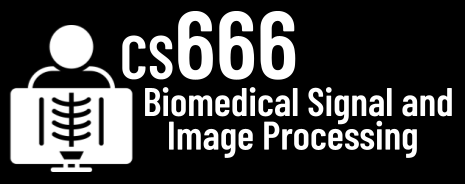
#Assignment 6

In [ ]:
# NAME: Amirhamzeh Khoshnam

In [ ]:
# In this assignment, we will visualize and explore a CT scan!

In [1]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# we are using pydicom, so lets install it!
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.0 MB/s eta 0:00:00


**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [ ]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [ ]:
# TODO: YOUR CODE

In [4]:
!wget https://cs666.org/data/ct.zip

--2026-05-06 23:45:53--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  23.3MB/s    in 0.2s    

2026-05-06 23:45:54 (23.3 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [ ]:
# Then use the following snippet to extract the data.

In [5]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there? Number of slices: 220

In [ ]:
# TODO: YOUR_ANSWER

In [8]:

import glob
dcm_files = sorted(glob.glob('**/*.dcm', recursive=True))
print(f"Number of slices: {len(dcm_files)}")

Number of slices: 220


In [9]:
import pydicom
import matplotlib.pyplot as plt

dcm_files_sorted = sorted(dcm_files)
ds = pydicom.dcmread(dcm_files_sorted[0])
print(ds)  # shows metadata

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7238010.5.1.4.0.75157.1397189444.4923
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7238010.5.0.3.5.4
(0002,0013) Implementation Version Name         SH: 'OSIRIX'
(0002,0016) Source Application Entity Title     AE: 'DicomBrowser'
-------------------------------------------------
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7238010.5.1.4.0.75157.1397189444.4923
(0008,0020) Study Date                          DA: '200

In [ ]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

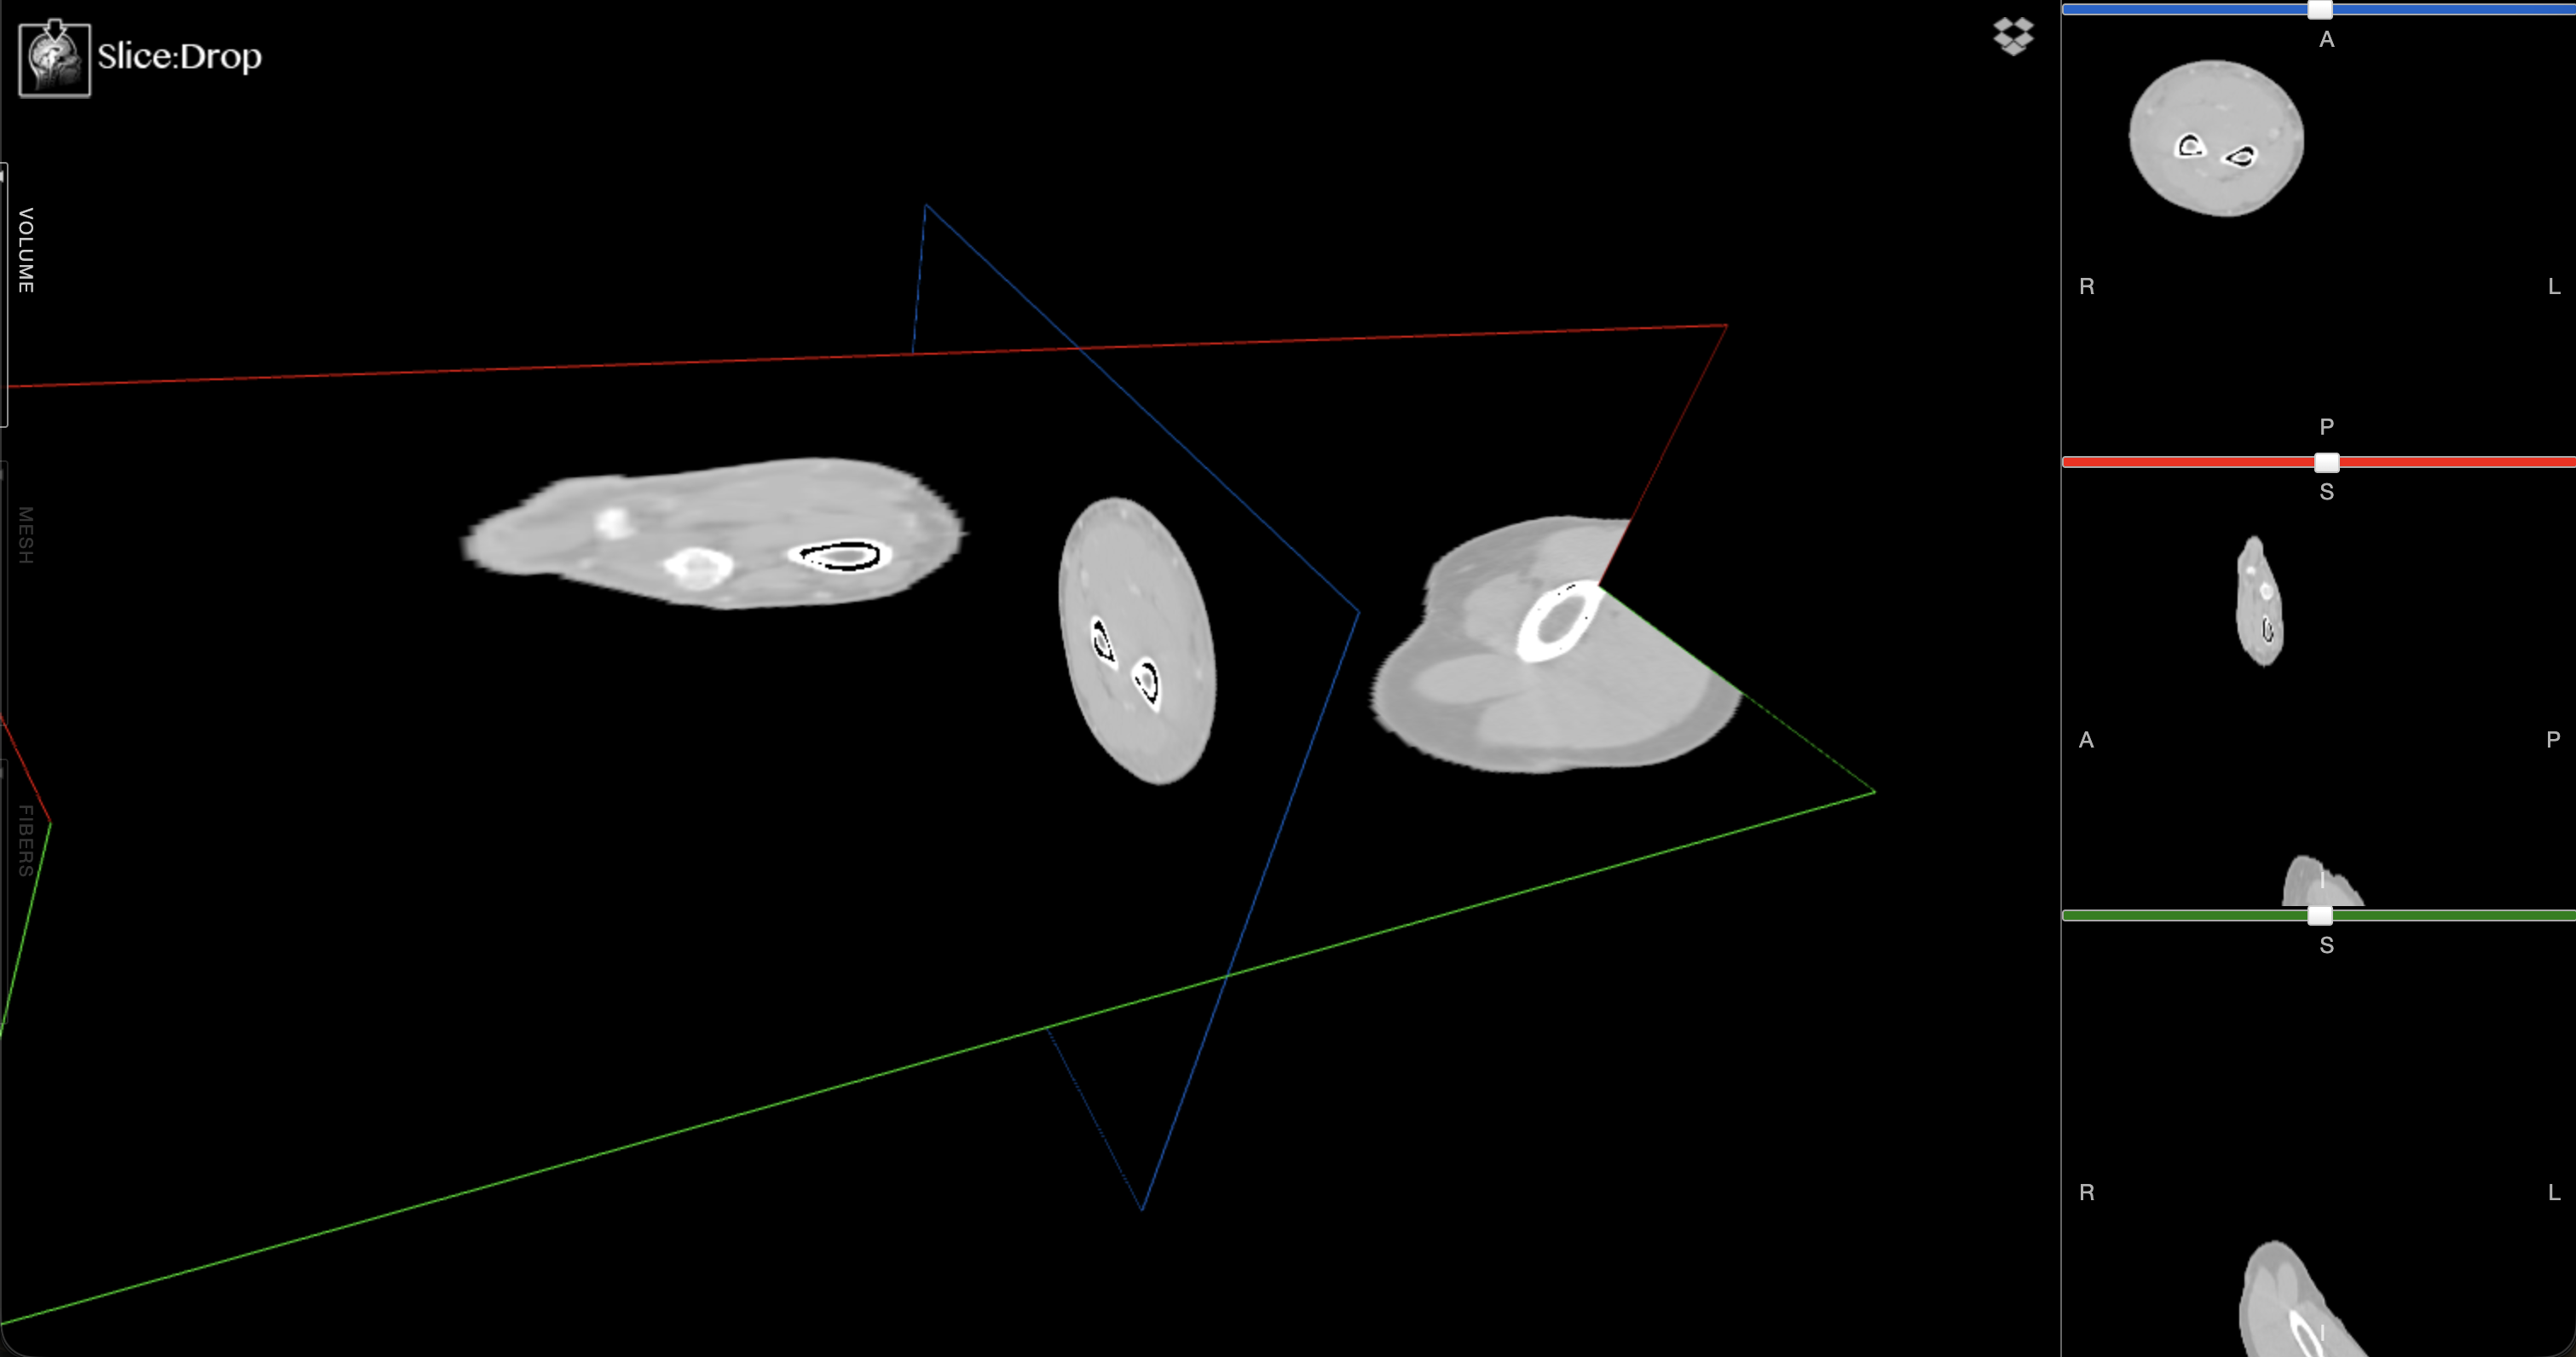

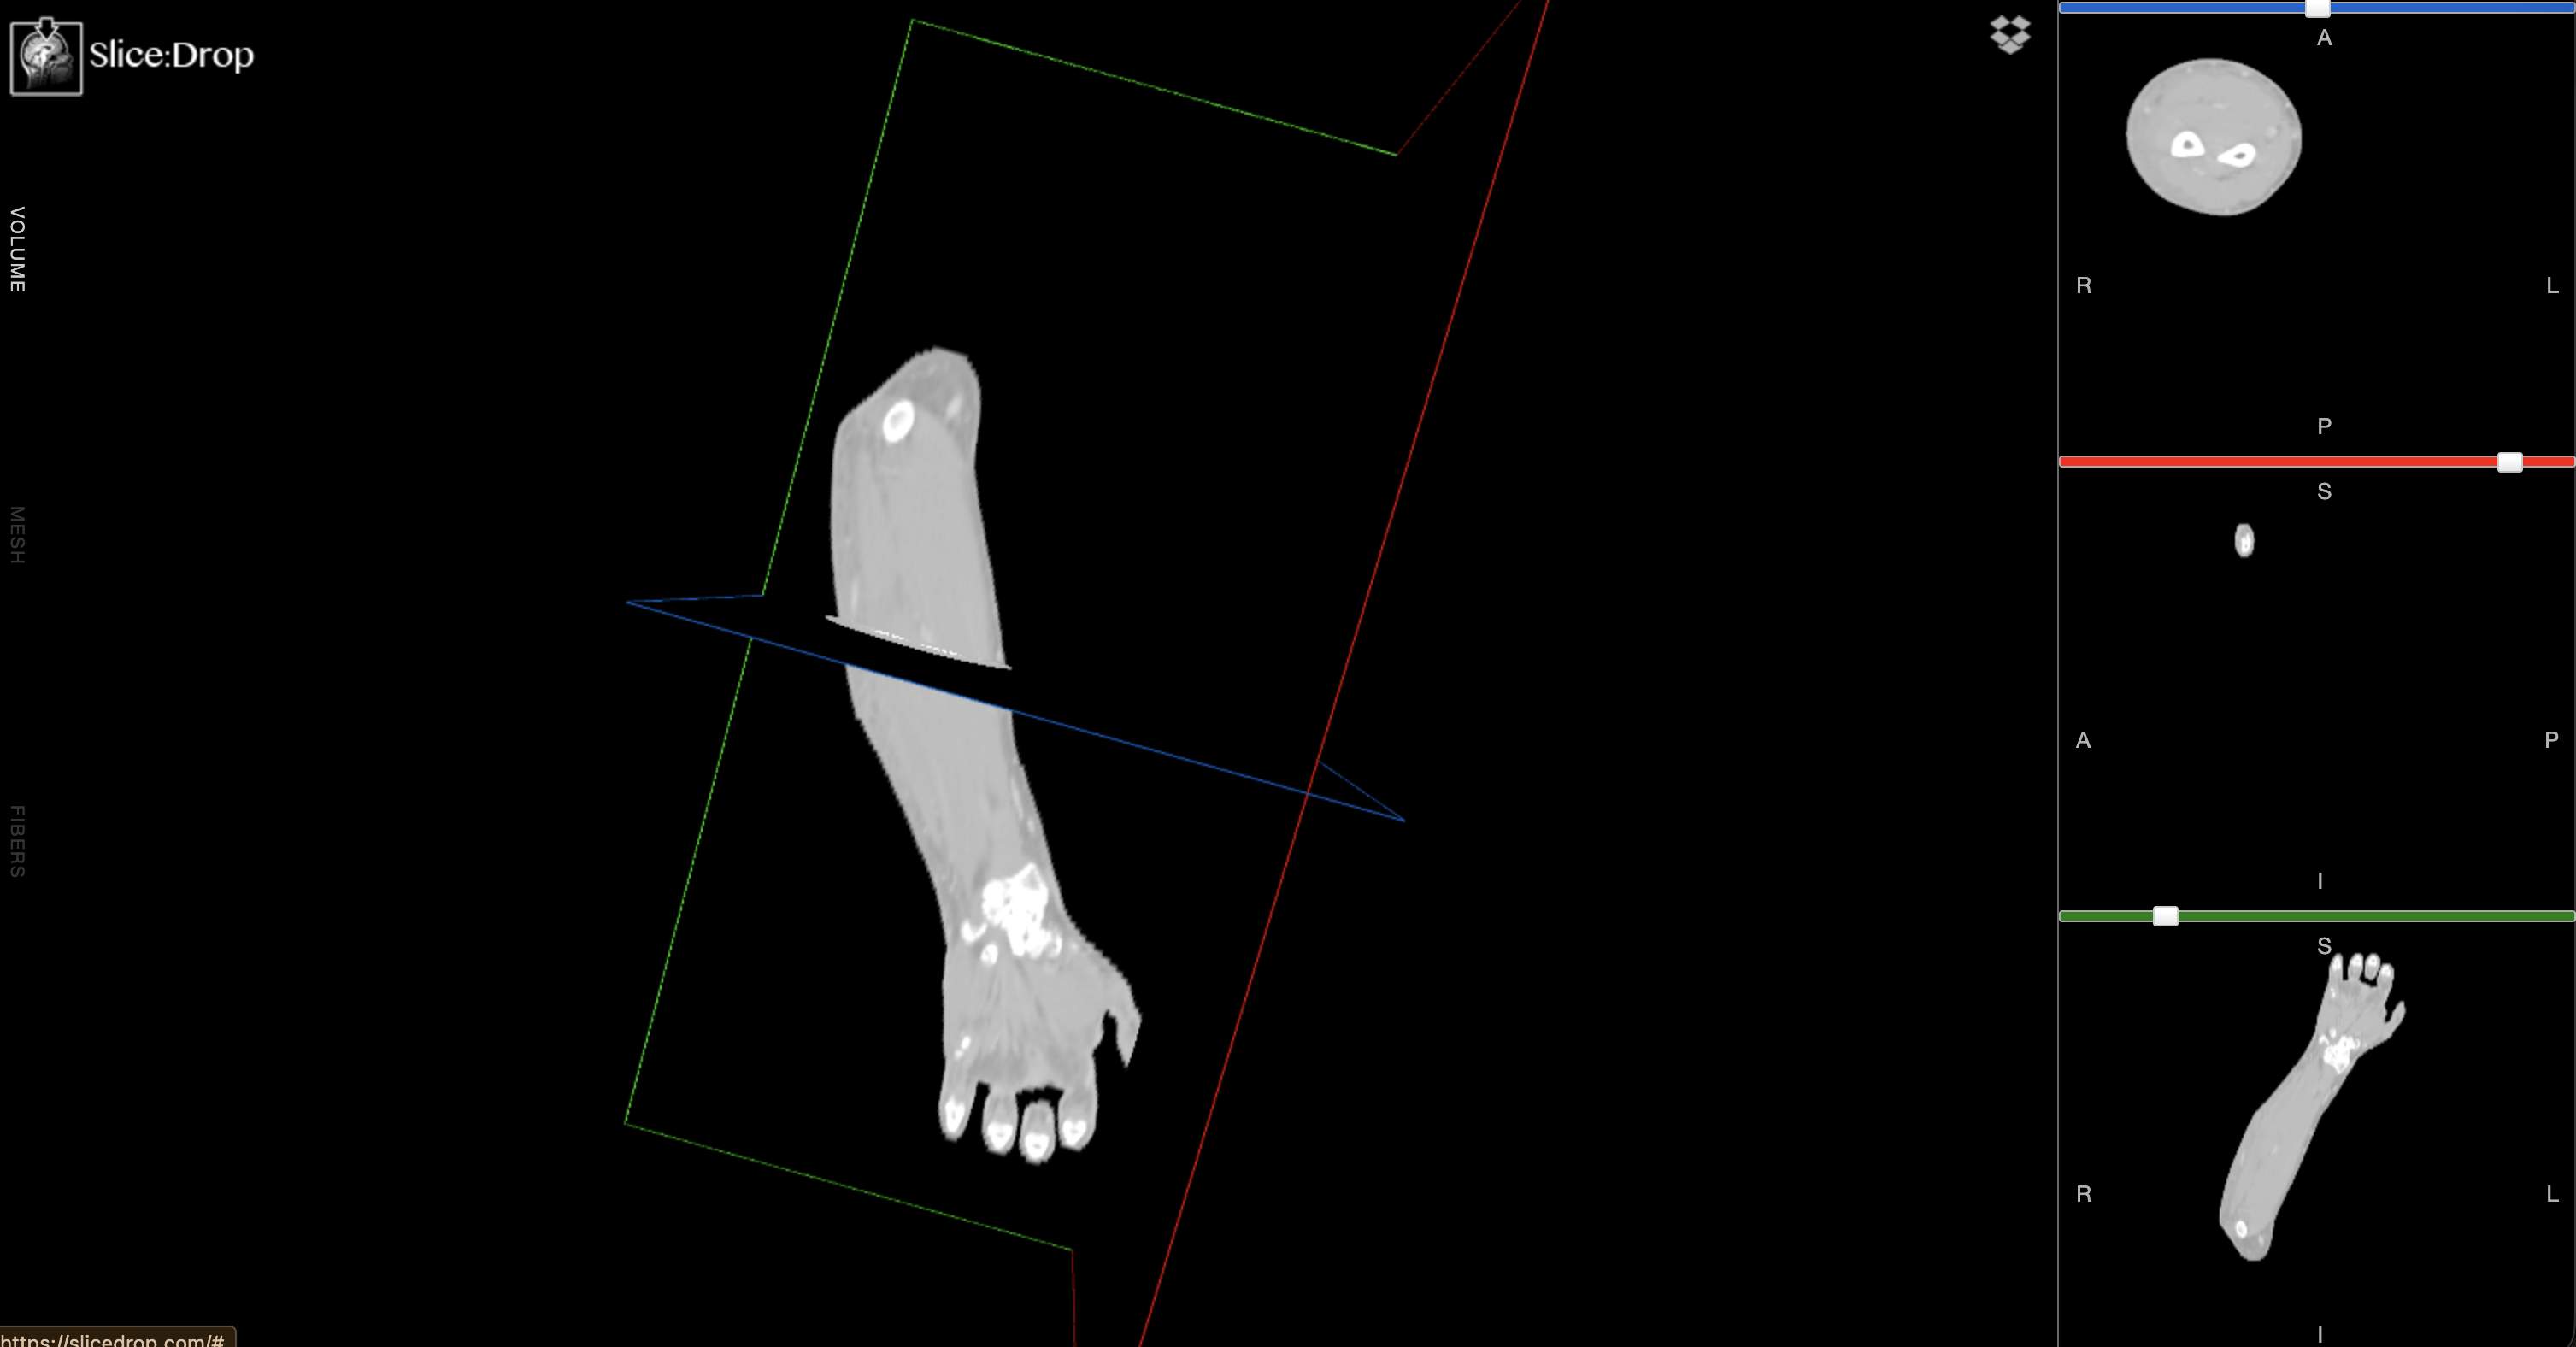

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

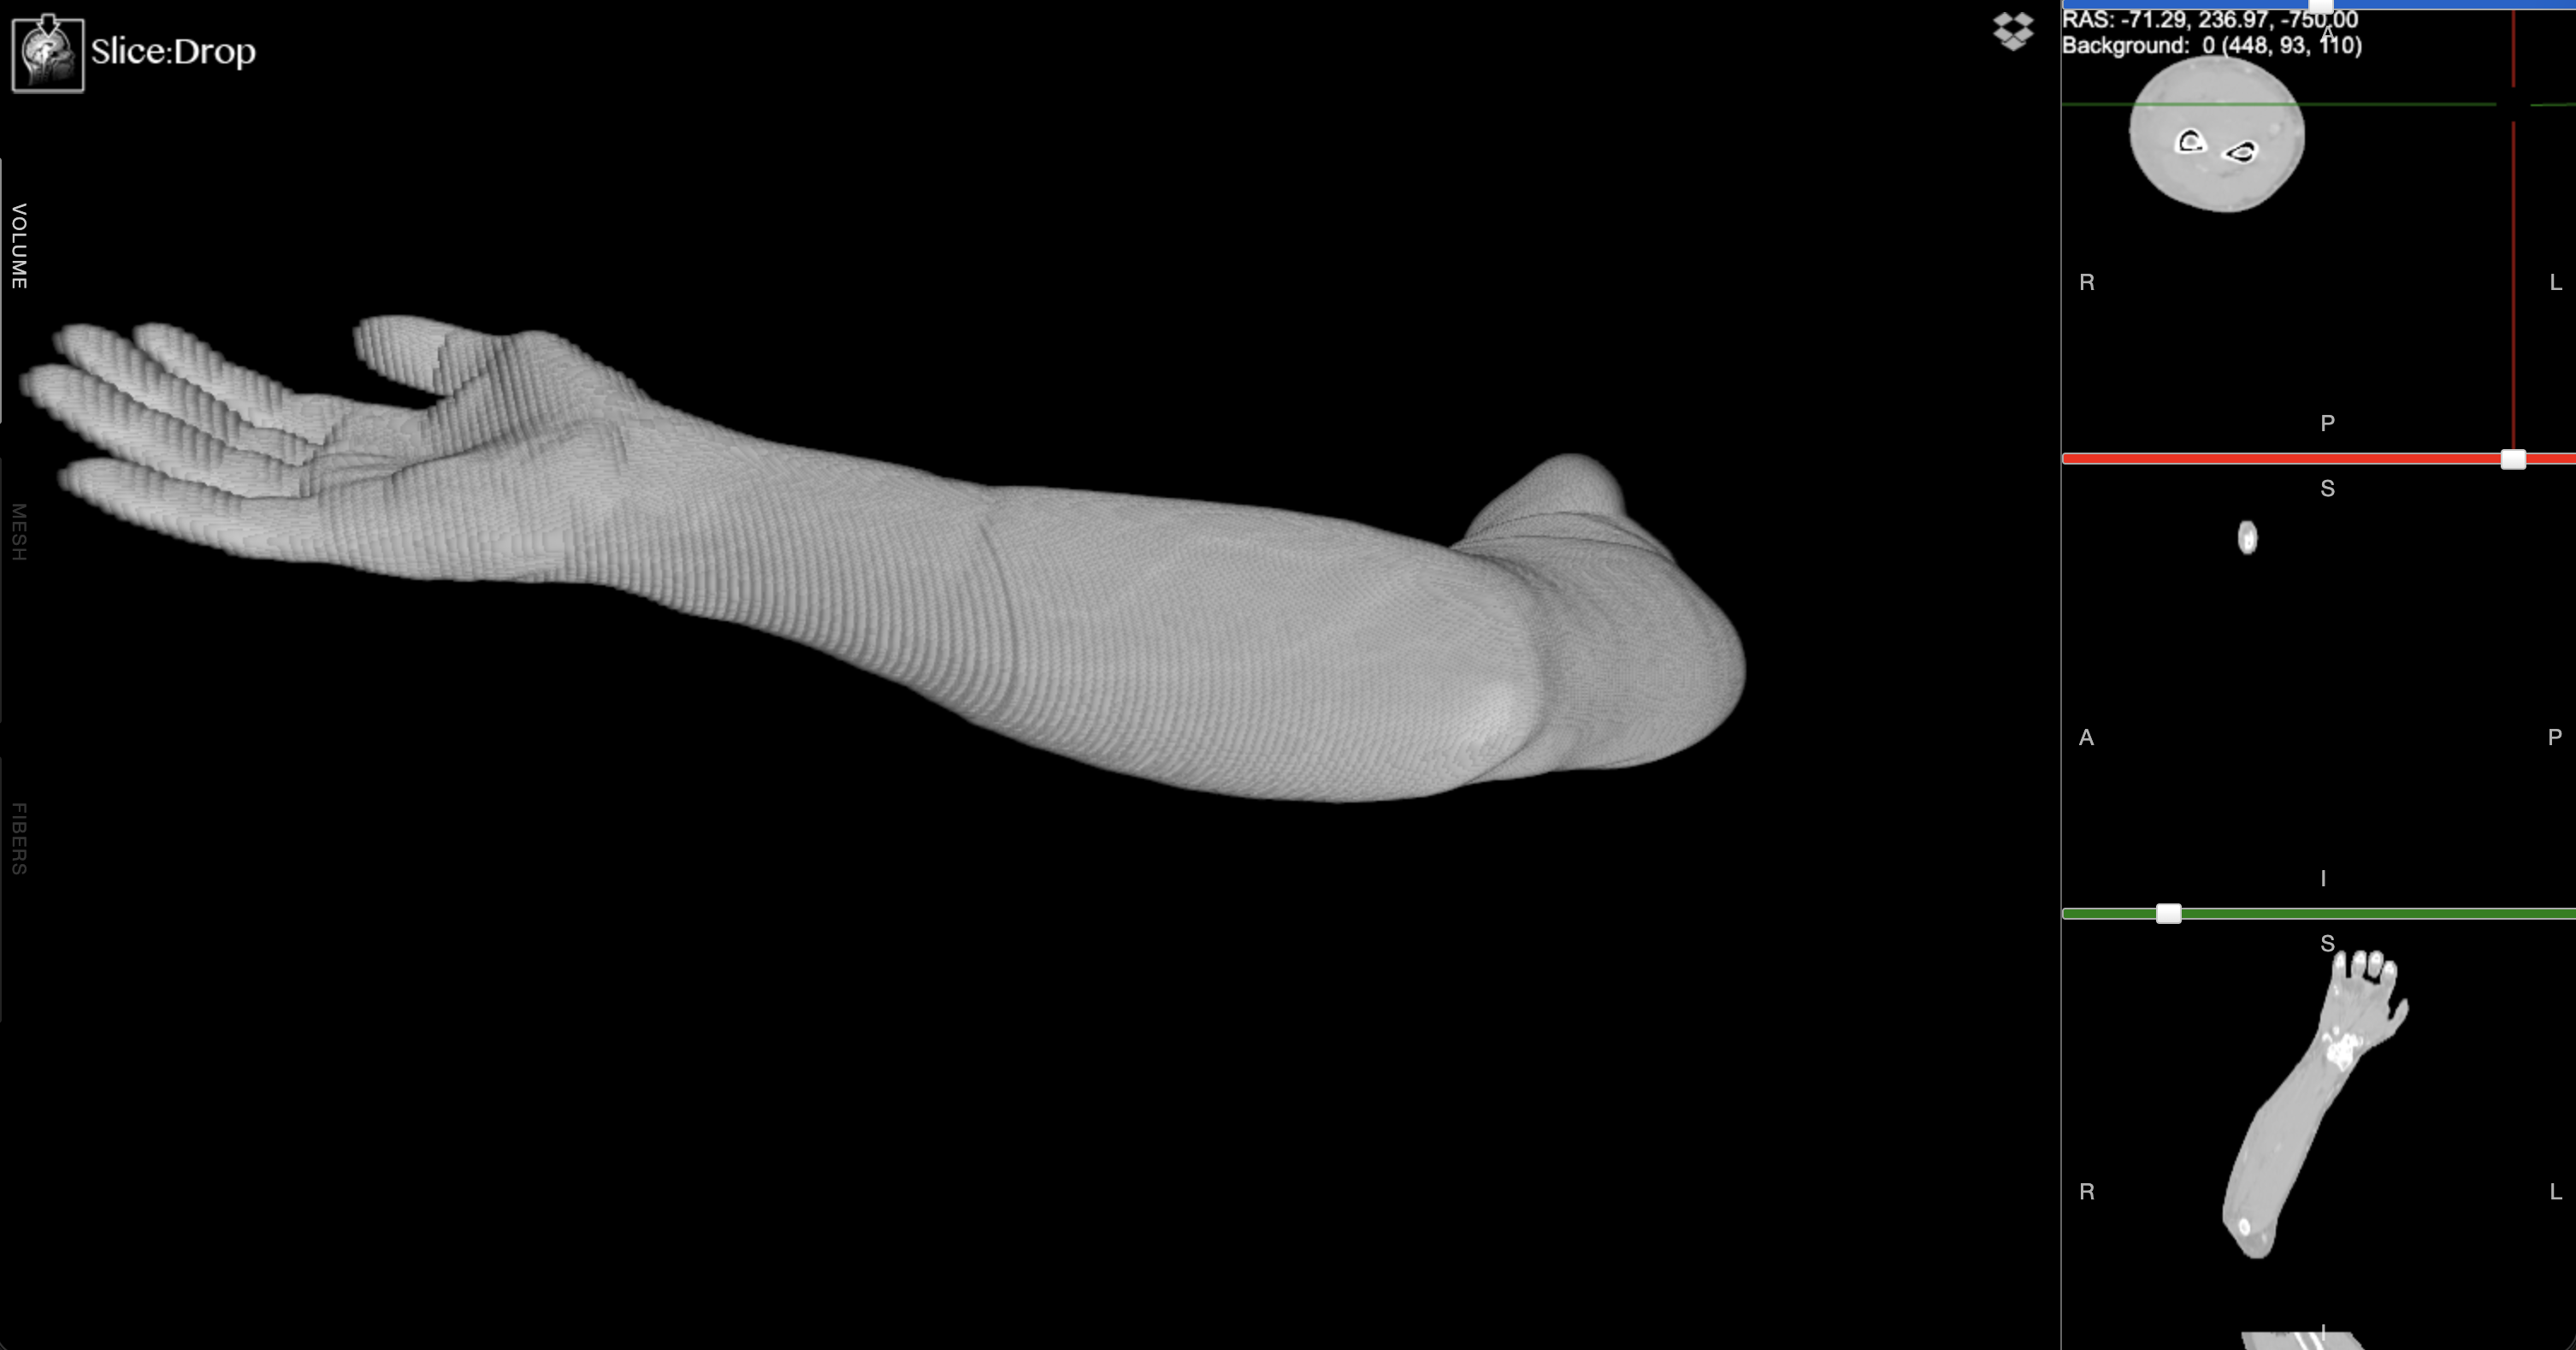

In [ ]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

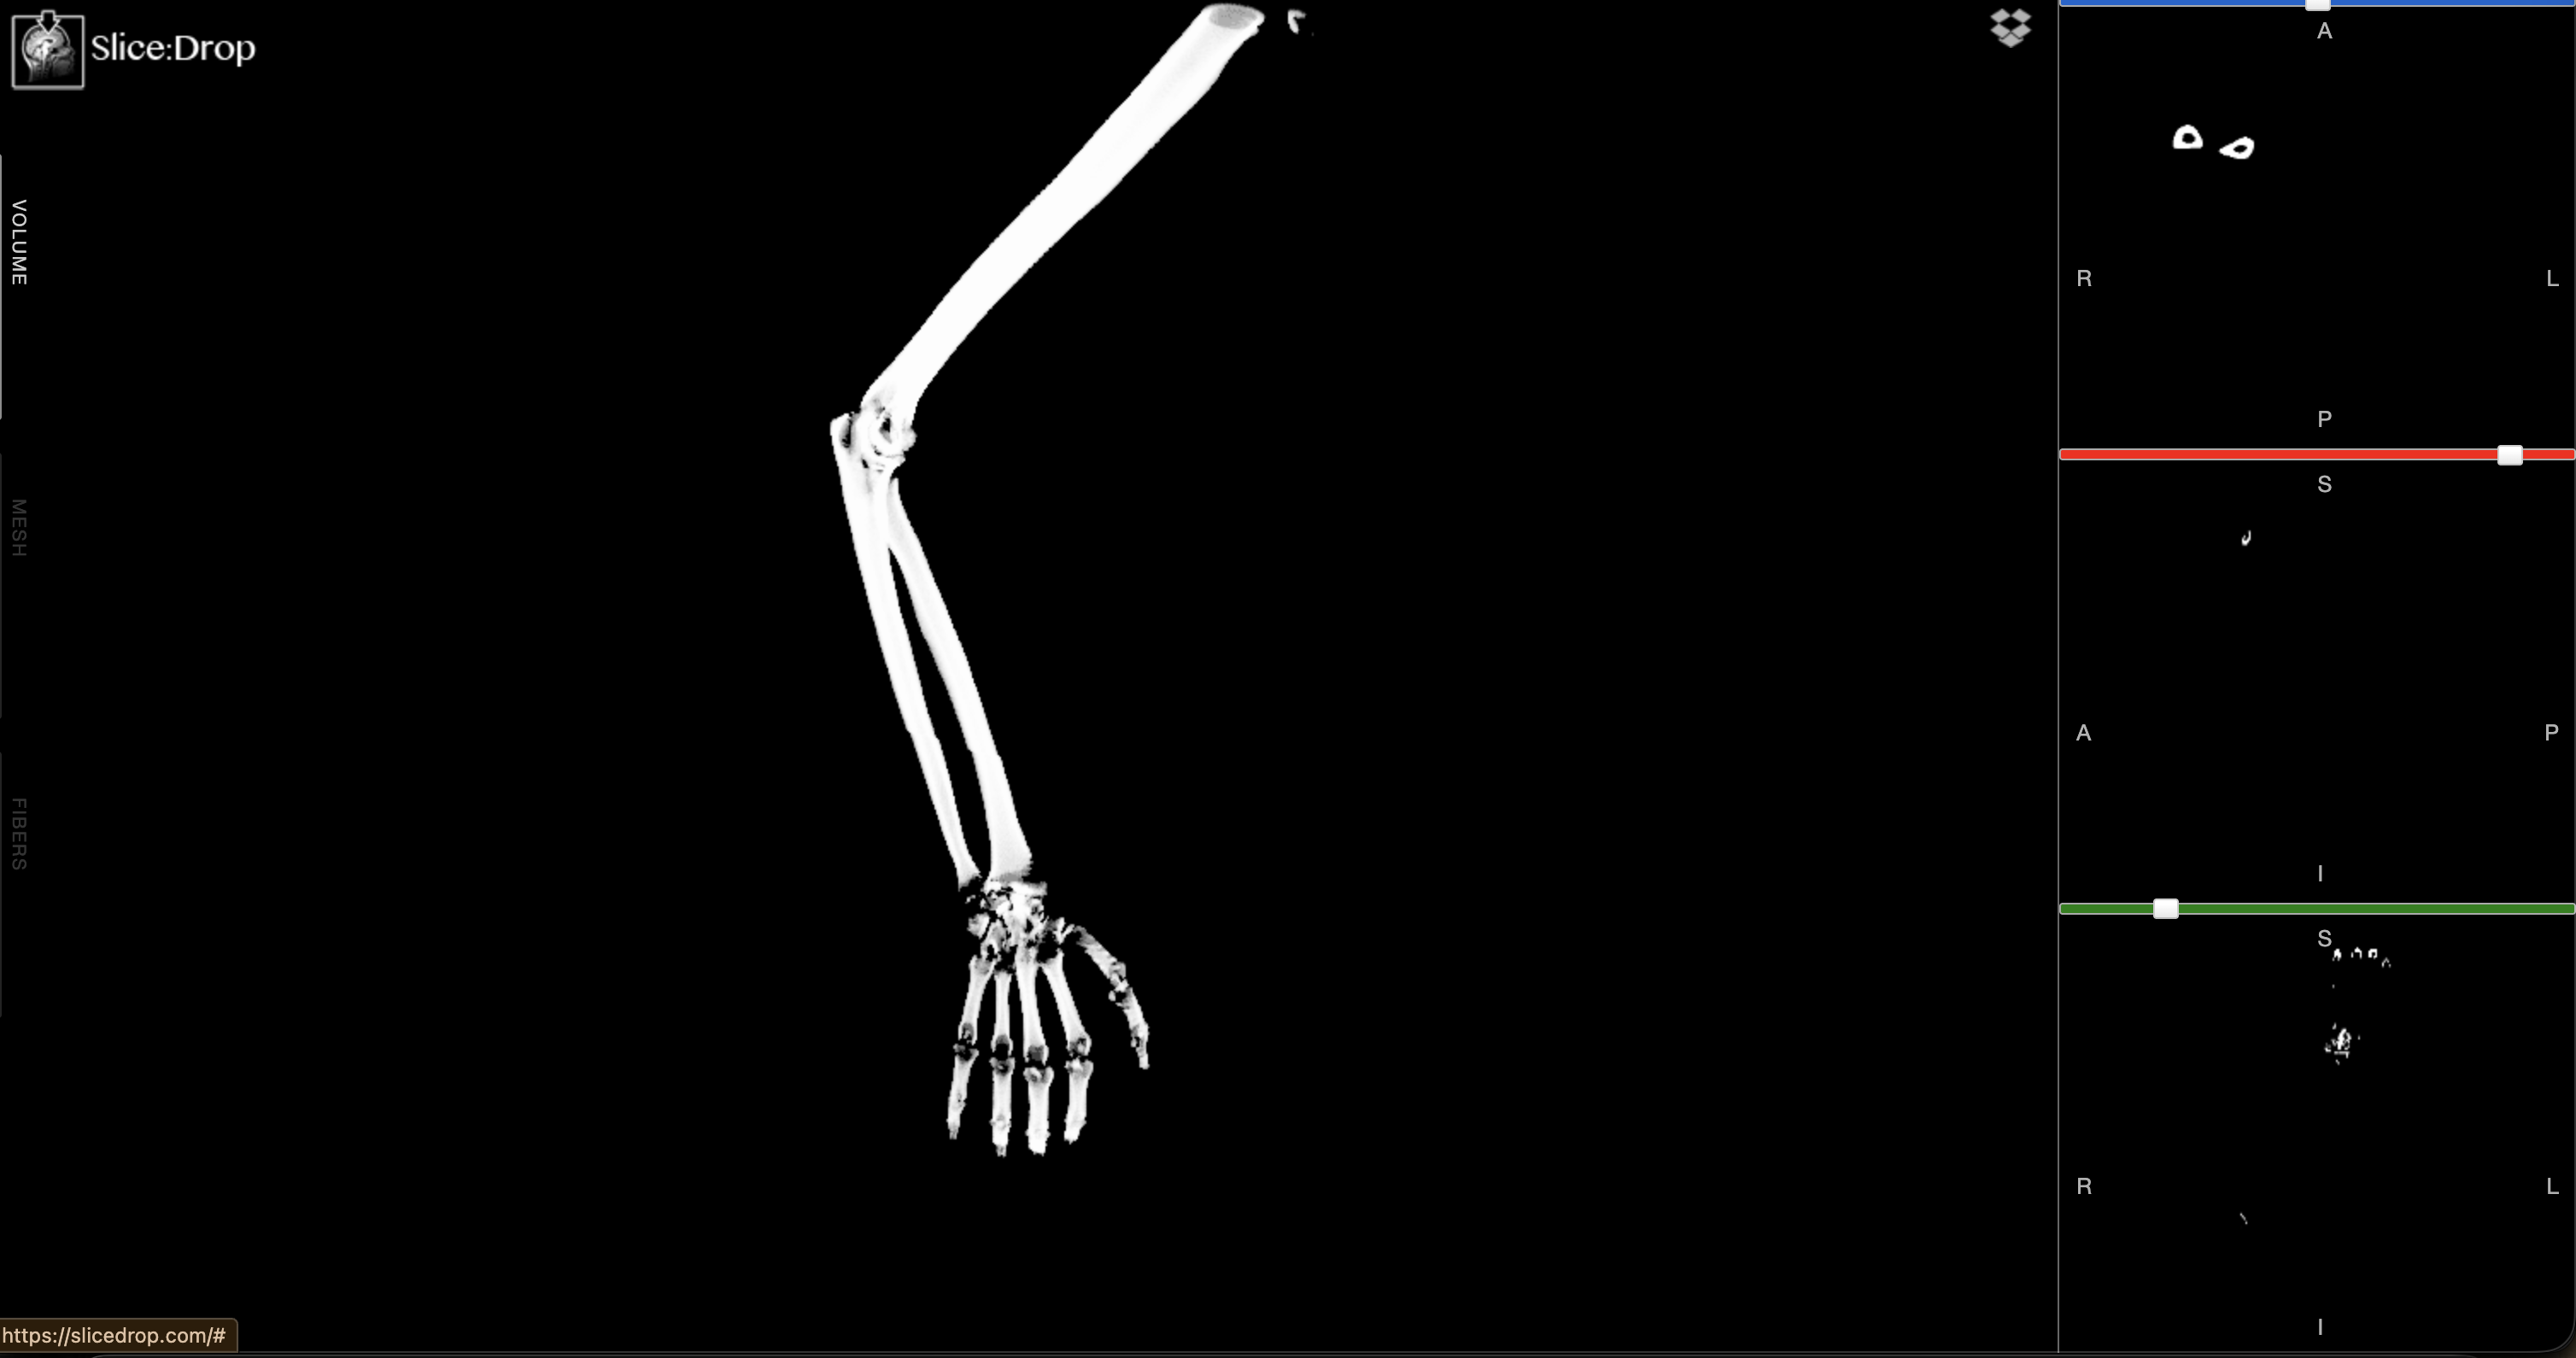

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [ ]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [ ]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY

In [12]:
import os
import numpy as np
from pydicom import dcmread

DIR = './ct'
files = sorted([f for f in os.listdir(DIR) if f.endswith('.dcm') and not f.startswith('.')])

# Read first slice to get dimensions
first = dcmread(os.path.join(DIR, files[0]))
rows, cols = first.pixel_array.shape

# Build 3D volume
volume = np.zeros((len(files), rows, cols), dtype=np.int16)
for i, f in enumerate(files):
    ds = dcmread(os.path.join(DIR, f))
    volume[i] = ds.pixel_array

print(f"Volume shape: {volume.shape}")

Volume shape: (220, 454, 512)


In [ ]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

In [ ]:
# TODO: YOUR CODE FOR AXIAL

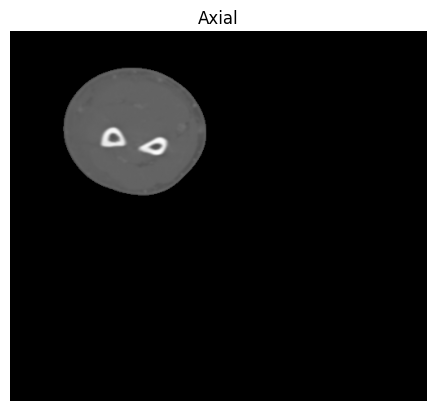

In [14]:
mid_axial = volume.shape[0] // 2
plt.imshow(volume[mid_axial, :, :], cmap='gray')
plt.title('Axial')
plt.axis('off')
plt.show()

In [ ]:
# TODO: YOUR CODE FOR SAGITTAL

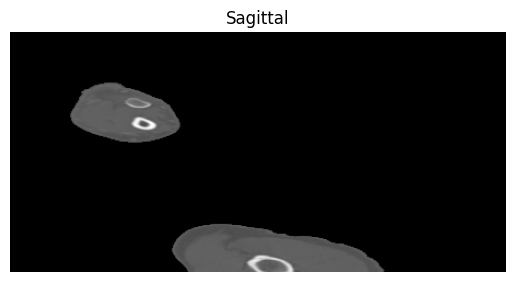

In [15]:

mid_sag = volume.shape[2] // 2
plt.imshow(volume[:, :, mid_sag], cmap='gray')
plt.title('Sagittal')
plt.axis('off')
plt.show()

In [ ]:
# TODO: YOUR CODE FOR CORONAL

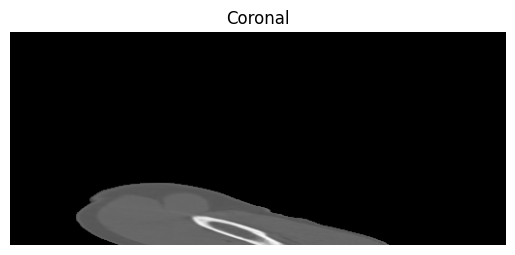

In [16]:
mid_cor = volume.shape[1] // 2
plt.imshow(volume[:, mid_cor, :], cmap='gray')
plt.title('Coronal')
plt.axis('off')
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [ ]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [ ]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [ ]:
# TODO: YOUR CODE

Window Center (Level): 30
Window Width: 410
Rescale Intercept: -1024


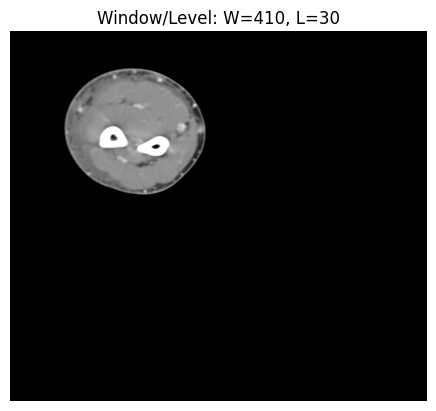

In [17]:

ds = dcmread(os.path.join(DIR, files[len(files)//2]))


level = ds[0x0028, 0x1050].value  # Window Center
window = ds[0x0028, 0x1051].value  # Window Width
rescale = ds[0x0028, 0x1052].value  # Rescale Intercept

print(f"Window Center (Level): {level}")
print(f"Window Width: {window}")
print(f"Rescale Intercept: {rescale}")

# Apply window/level
hu_pixels = ds.pixel_array
vmin = level - window / 2
vmax = level + window / 2

plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f'Window/Level: W={window}, L={level}')
plt.axis('off')
plt.show()

In [ ]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

In [ ]:
# TODO: YOUR CODE

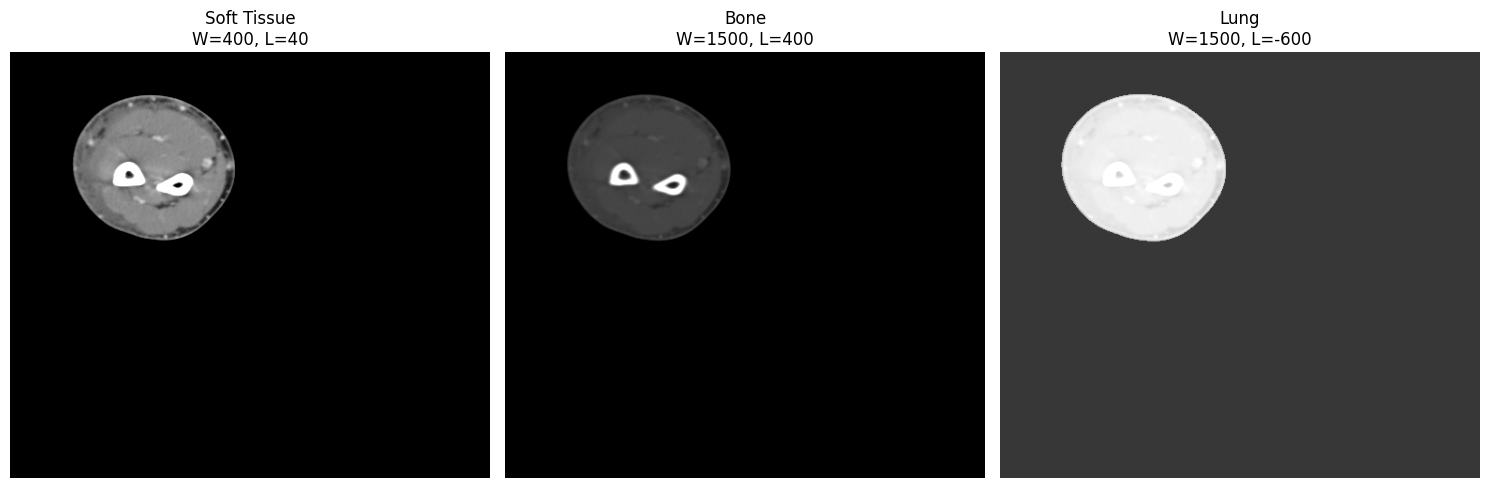

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

settings = [
    ("Soft Tissue", 400, 40),    # W=400, L=40
    ("Bone",        1500, 400),  # W=1500, L=400
    ("Lung",        1500, -600), # W=1500, L=-600
]

for ax, (title, w, l) in zip(axes, settings):
    vmin = l - w / 2
    vmax = l + w / 2
    ax.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'{title}\nW={w}, L={l}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Which values make sense and why?

In [19]:
# TODO: YOUR ANSWER

# The Soft Tissue window (W=400, L=40) makes the most sense for this arm CT.
# The level=40 HU centers on soft tissue density, and the narrow window=400
# provides high contrast between muscle (~40 HU), fat (~-100 HU), and bone (>400 HU).
# The bone window (W=1500, L=400) would be better if we only cared about
# bone detail. The lung window is not meaningful here since there is no air-filled
# tissue in an arm scan.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [ ]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

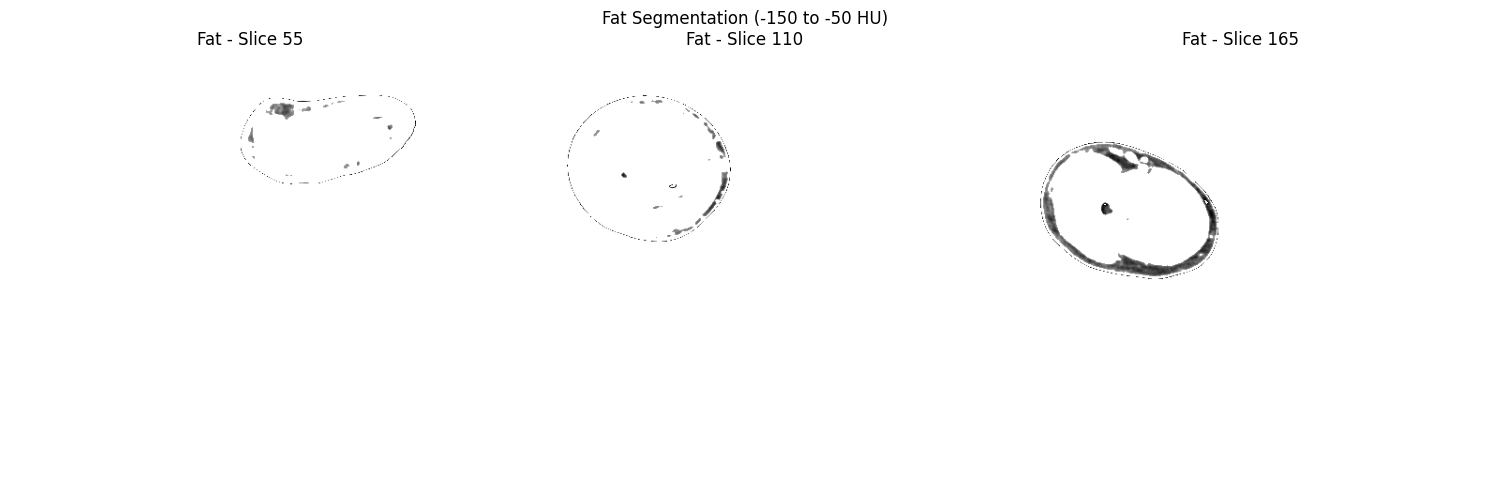

In [20]:
# TODO: YOUR CODE TO SEGMENT FAT

# HU range for fat: -150 to -50
hu_volume = volume.astype(np.int16) + rescale  # apply rescale intercept

fat_mask = hu_volume.copy()
fat_mask[(hu_volume < -150) | (hu_volume > -50)] = 0

# Show 3 slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    idx = volume.shape[0] // 4 * (i + 1)
    ax.imshow(fat_mask[idx], cmap='gray')
    ax.set_title(f'Fat - Slice {idx}')
    ax.axis('off')
plt.suptitle('Fat Segmentation (-150 to -50 HU)')
plt.tight_layout()
plt.show()

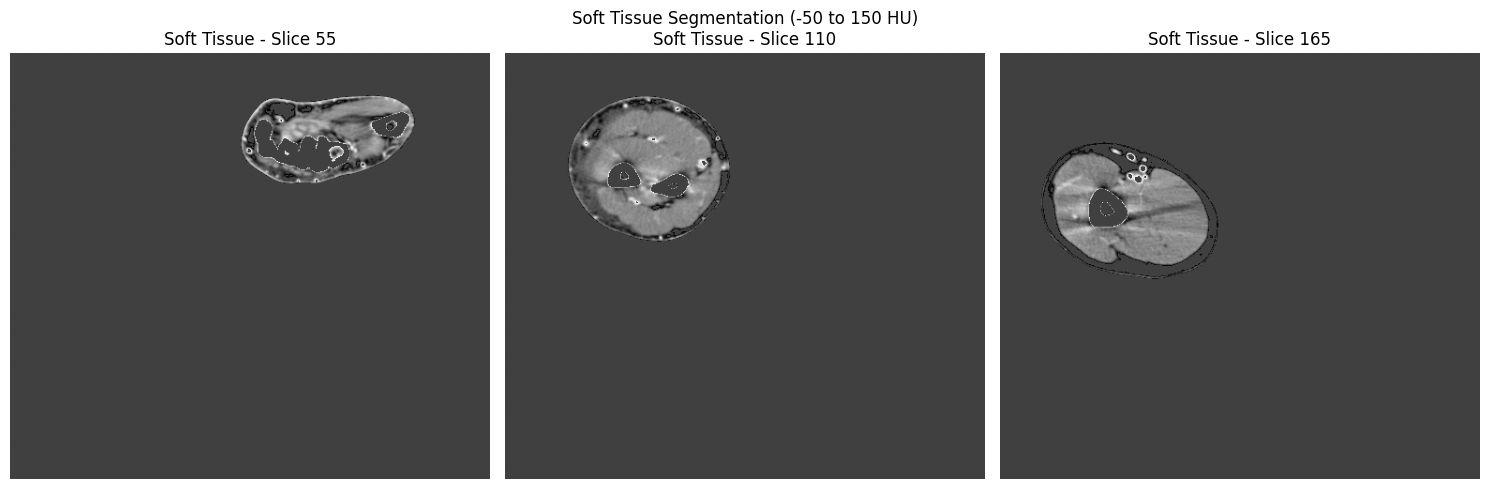

In [21]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE

# HU range for soft tissue: -50 to 150
soft_mask = hu_volume.copy()
soft_mask[(hu_volume < -50) | (hu_volume > 150)] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    idx = volume.shape[0] // 4 * (i + 1)
    ax.imshow(soft_mask[idx], cmap='gray')
    ax.set_title(f'Soft Tissue - Slice {idx}')
    ax.axis('off')
plt.suptitle('Soft Tissue Segmentation (-50 to 150 HU)')
plt.tight_layout()
plt.show()

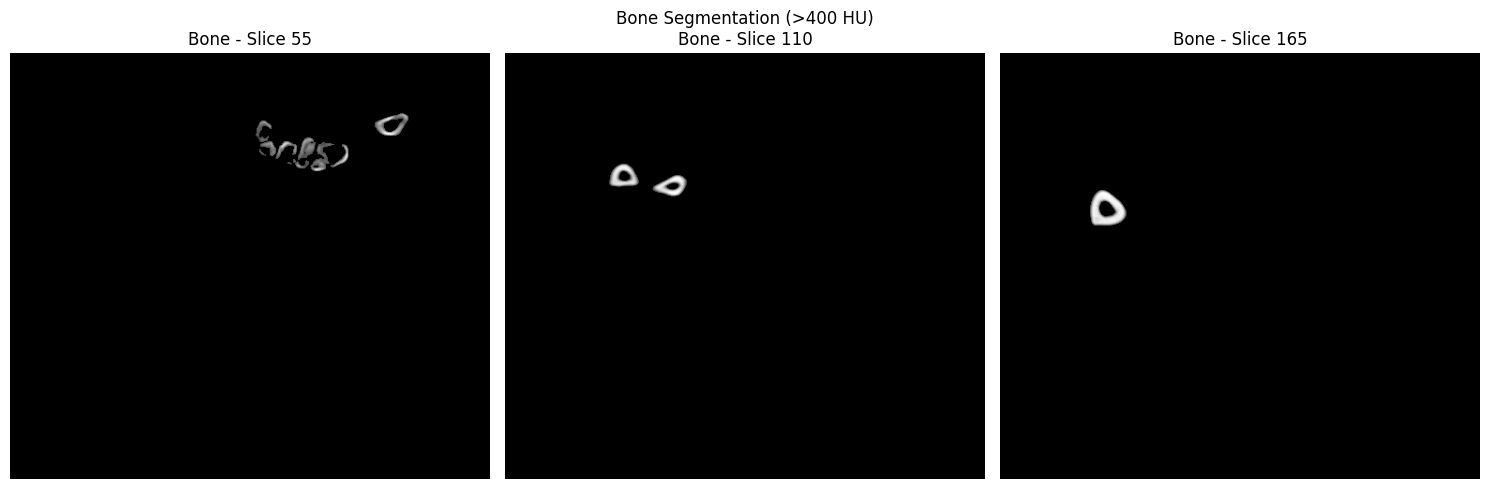

In [22]:
# TODO: YOUR CODE TO SEGMENT BONES

# HU range for bone: 400+
bone_mask = hu_volume.copy()
bone_mask[hu_volume < 400] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    idx = volume.shape[0] // 4 * (i + 1)
    ax.imshow(bone_mask[idx], cmap='gray')
    ax.set_title(f'Bone - Slice {idx}')
    ax.axis('off')
plt.suptitle('Bone Segmentation (>400 HU)')
plt.tight_layout()
plt.show()

In [ ]:
# Are the segmentations good?

In [23]:
# TODO: YOUR ANSWER

# The bone segmentation is very clean — cortical bone has distinctly high HU (>400)
# so thresholding works well with minimal false positives.
#
# Soft tissue segmentation is reasonable but imperfect — the HU ranges of muscle,
# blood vessels, and connective tissue overlap, so some mixing occurs.
#
# Fat segmentation is decent but may include some air pockets near the skin boundary
# which also fall in the negative HU range. Morphological post-processing
# (e.g. erosion/dilation) could clean up the masks further.

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""